# Feature Exploration

## Multimodal Deepfake Lip-Sync Anomaly Detector

This notebook explores the multimodal features used in the Deepfake
Lip-Sync Anomaly Detection system.

The system analyzes the relationship between:

- Visual lip movement
- Spoken audio features
- Temporal synchronization

The final multimodal representation is used by an LSTM-based
deep learning model to classify a video as:

- REAL
- FAKE

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

# Project Structure

This notebook is located inside the `notebooks` directory.

We identify the project root so that project modules and files
can be accessed during experimentation.

In [2]:
PROJECT_ROOT = Path.cwd().parent

print("Project Root:")
print(PROJECT_ROOT)

Project Root:
/Users/rajeshverma/Desktop/Developer/Deepfake-LipSync-Detector


# Multimodal Feature Architecture

The final inference pipeline combines visual and audio information.

## Visual Features

The visual component represents lip movement extracted from the
speaker's face.

The project uses MediaPipe Face Mesh to track facial landmarks.

## Audio Features

The audio component is represented using MFCC
(Mel-Frequency Cepstral Coefficients).

## Multimodal Fusion

Visual and audio features are combined to create a multimodal
representation that can be analyzed over time.

In [3]:
VISUAL_FEATURES = 80
AUDIO_FEATURES = 39

TOTAL_FEATURES = (
    VISUAL_FEATURES
    + AUDIO_FEATURES
)

SEQUENCE_LENGTH = 150

print("Visual Features :", VISUAL_FEATURES)
print("Audio Features  :", AUDIO_FEATURES)
print("Total Features  :", TOTAL_FEATURES)
print("Sequence Length :", SEQUENCE_LENGTH)

Visual Features : 80
Audio Features  : 39
Total Features  : 119
Sequence Length : 150


# Feature Distribution

The multimodal input contains two main feature groups:

1. Visual lip movement features
2. Audio MFCC features

The following visualization shows the number of features
contributed by each modality.

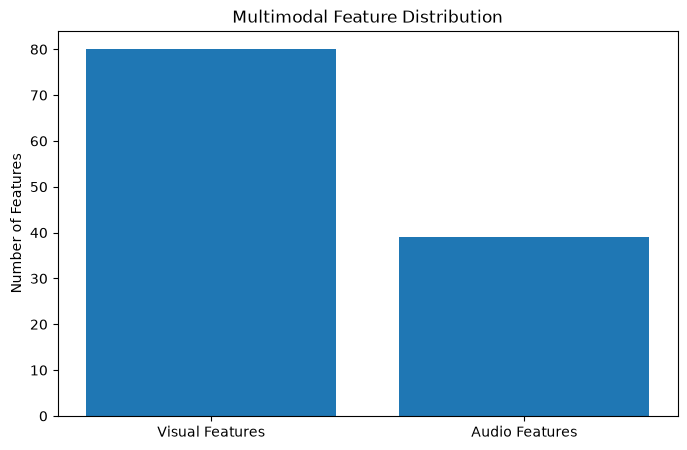

In [4]:
feature_names = [
    "Visual Features",
    "Audio Features"
]

feature_counts = [
    VISUAL_FEATURES,
    AUDIO_FEATURES
]

plt.figure(figsize=(8, 5))

plt.bar(
    feature_names,
    feature_counts
)

plt.title(
    "Multimodal Feature Distribution"
)

plt.ylabel(
    "Number of Features"
)

plt.show()

# Temporal Input Representation

The deep learning model does not analyze only a single frame.

Instead, it analyzes a sequence of multimodal feature vectors.

Each temporal step contains:

119 features

The complete input sequence contains:

150 temporal steps

Therefore, a single video-level model input follows the
general structure:

(150, 119)

In [5]:
input_shape = (
    SEQUENCE_LENGTH,
    TOTAL_FEATURES
)

print(
    "Single sequence input shape:",
    input_shape
)

Single sequence input shape: (150, 119)


# Example Multimodal Sequence

The following code creates a synthetic example sequence.

This is not real video data.

It is used only to demonstrate the shape of the data
that the LSTM model receives.

In [6]:
example_sequence = np.random.rand(
    SEQUENCE_LENGTH,
    TOTAL_FEATURES
)

print(
    "Example sequence shape:"
)

print(
    example_sequence.shape
)

Example sequence shape:
(150, 119)


# Visualizing Temporal Features

Each row in the sequence represents one temporal step.

Each column represents one feature.

The following visualization displays a small portion of
the multimodal feature sequence.

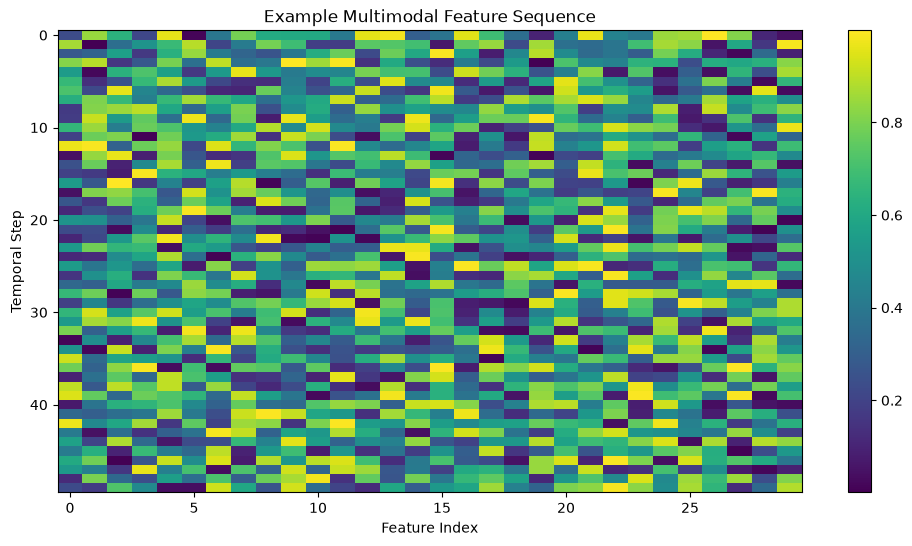

In [7]:
plt.figure(figsize=(12, 6))

plt.imshow(
    example_sequence[:50, :30],
    aspect="auto"
)

plt.title(
    "Example Multimodal Feature Sequence"
)

plt.xlabel(
    "Feature Index"
)

plt.ylabel(
    "Temporal Step"
)

plt.colorbar()

plt.show()

# Model Input

For inference, the LSTM model expects a batch dimension.

A single sequence:

(150, 119)

is converted into:

(1, 150, 119)

where:

- 1 represents batch size
- 150 represents temporal sequence length
- 119 represents multimodal features

In [8]:
model_input = np.expand_dims(
    example_sequence,
    axis=0
)

print(
    "Model input shape:"
)

print(
    model_input.shape
)

Model input shape:
(1, 150, 119)


# Multimodal Deepfake Detection Pipeline

The overall feature processing workflow is:

Video
↓
Face Detection and Face Mesh
↓
Lip Movement Features
↓
Audio Extraction
↓
MFCC Features
↓
Audio + Visual Feature Fusion
↓
Temporal Sequence Construction
↓
LSTM Model
↓
REAL / FAKE Prediction

# Conclusion

This notebook explored the multimodal feature representation used
by the Deepfake Lip-Sync Anomaly Detector.

The main components are:

- 80 visual features
- 39 audio features
- 119 total multimodal features
- 150 temporal steps

These multimodal temporal features are provided to an LSTM-based
model for video-level deepfake classification.

Future extensions of this notebook may include:

- Real lip landmark visualization
- Actual MFCC visualization
- Feature distribution analysis
- Real versus fake feature comparison
- Temporal synchronization analysis